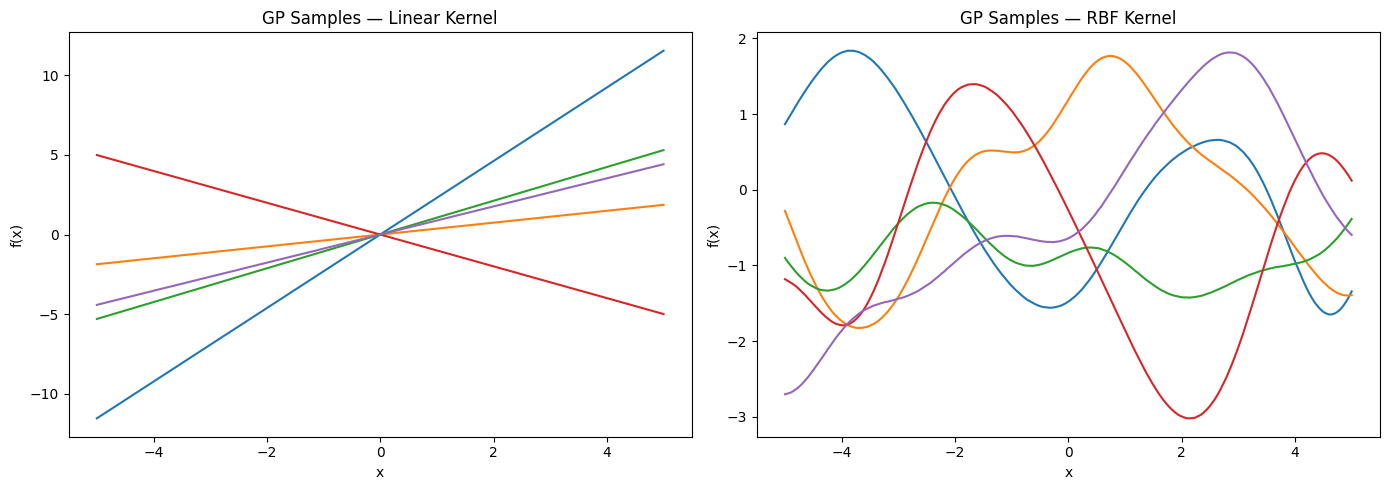

In [2]:
import torch
import matplotlib.pyplot as plt

# --------- Linear Kernel ---------
def linear_kernel(X, variance=1.0):
    X = X.double()
    return variance * (X @ X.T)

# --------- RBF Kernel ---------
def rbf_kernel(X, lengthscale=1.0, variance=1.0):
    X = X.double()
    sq = (X**2).sum(dim=1, keepdim=True) 
    d2 = sq + sq.T - 2 * (X @ X.T)
    return variance * torch.exp(-0.5 * d2 / (lengthscale**2))

# --------- GP Sampling ---------
def sample_gp(X, num_samples, kernel_fn, jitter=1e-6, **kernel_args):
    X = X.double()
    K = kernel_fn(X, **kernel_args)
    n = K.shape[0]

    # Stability
    K = K + jitter * torch.eye(n, dtype=K.dtype)

    # Cholesky
    L = torch.linalg.cholesky(K)

    # Draw many samples at once
    eps = torch.randn(n, num_samples, dtype=torch.double)
    Y = L @ eps  # (n, num_samples)

    return Y.T, K   # (num_samples, n)

# ============================================================
#                EXAMPLE: DRAW GP SAMPLE CURVES
# ============================================================

torch.manual_seed(0)

# 1D input for plotting
n = 200
X = torch.linspace(-5, 5, n).reshape(-1, 1)   # shape (n, 1)

# Number of samples per kernel
num_samples = 5

# ---- Linear GP samples ----
Y_lin, K_lin = sample_gp(
    X,
    num_samples=num_samples,
    kernel_fn=linear_kernel,
    variance=1.0
)

# ---- RBF GP samples ----
Y_rbf, K_rbf = sample_gp(
    X,
    num_samples=num_samples,
    kernel_fn=rbf_kernel,
    variance=1.0,
    lengthscale=1.2
)

# ============================================================
#                         PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Linear Kernel GP ---
for i in range(num_samples):
    axes[0].plot(X.numpy(), Y_lin[i].numpy())
axes[0].set_title("GP Samples — Linear Kernel")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")

# --- RBF Kernel GP ---
for i in range(num_samples):
    axes[1].plot(X.numpy(), Y_rbf[i].numpy())
axes[1].set_title("GP Samples — RBF Kernel")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.savefig('gp_samples_linear_rbf_kernels.png')
plt.show()
